# Immersive 3-D visualisation of AMR data

`projection` is **orthographic** (parallel rays). **Immersive** rendering puts a camera *at a point* and
shoots rays outward — perspective fly-ins, 360° panoramas, fisheye/dome masters, multi-tracer composites,
isosurfaces — marching the **AMR octree directly** (no uniform-grid resample), so cost scales with the data,
not the bounding box.

This notebook is a **ladder**: each rung shows a result first, then the one parameter that produced it,
then builds toward **quantitative, publication-grade** maps (column density, mock emission, kinematics).

**Performance.** Renders are multithreaded — use the **8-thread Julia kernel** (`Threads.nthreads()` below
should be > 1). For a huge box: `subregion` before `amr_volume`, preview with `smooth=false`/coarse `pxsize`,
final frame with `smooth=true, aa=2`. `show_progress=true` shows a bar.

In [1]:
using Mera, CairoMakie
CairoMakie.activate!()
println("threads = ", Threads.nthreads(), "   (use the 8-thread kernel for fast renders)")


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0

threads = 8

   (use the 8-thread kernel for fast renders)


## 1 · Load, and the minimal pipeline

Five lines: load gas → index it → place a camera → render → show. Zero tuning parameters. Camera positions
are code units; `boxcenter`/`boxspan` make them box-relative (`eye(fx,fy,fz)`), so the same recipe frames
*any* box size.

> **The `eye` helper.** `eye(fx,fy,fz) = bc .+ boxspan(vol).*(fx,fy,fz)` places the camera **relative to the box**: `fx,fy,fz` are fractions of the box size measured from the centre `bc`. So `eye(0.3,0.2,0.24)` sits 0.3·boxlen right, 0.2 up-y, 0.24 up-z of centre — the *same framing on any sim*, no hard-coded code units. **Avoid exact axis values** like `eye(0,0,0.6)` (straight down a grid axis): that lines every ray up with the cell grid and makes concentric-ring / lattice aliasing — keep a small lateral offset, e.g. `eye(0.12,0.08,0.6)`.


In [2]:
base = get(ENV, "MERA_TEST_DATA", "/Volumes/FASTStorage/Simulations/AVALONpaper")
path = joinpath(base, "AV05CDhr/mera_v2/")
info = infodata(390, path, verbose=false)
gas  = loaddata(390, path, :hydro, verbose=false)
# Big & slow? Zoom first (also lets finer pxsize render fast):
# MEMORY: a full deep box is heavy — gas + vol for a 167M-cell run is ~10+ GB; if you hit OOM /
# a kernel restart, zoom FIRST (uncomment) so neither data nor index is ever held at full size:
# gas = subregion(gas, :cylinder; center=[:boxcenter], radius=15., height=4., direction=:z, range_unit=:kpc)

vol = amr_volume(gas, :rho, :nH)
bc  = boxcenter(vol)
eye(fx,fy,fz) = bc .+ boxspan(vol) .* (fx,fy,fz)     # box-relative camera offset → works on any boxlen
println("boxlen=", vol.boxlen, "  nleaf=", vol.nleaf)
println("nH  range (log10): ", round.(log10.(extrema(filter(>(0), getvar(gas,:rho,:nH)))), digits=2))
println("T   range (log10): ", round.(log10.(extrema(filter(>(0), getvar(gas,:T,:K)))), digits=2))

amr_volume: 166991609 leaves, levels 6–13, boxlen 48.0 [code]  (no uniform grid — native AMR marching)


┌ Warning: amr_volume indexed 166991609 leaves (~6.7 GB of index, lookups descend 8 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122


boxlen=48.0  nleaf=166991609
nH  range (log10): 

(-6.53, 3.91)
T   range (log10): 

(1.04, 8.74)


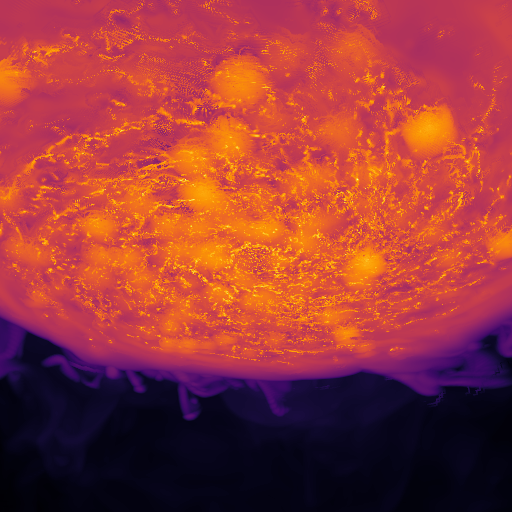

In [3]:
# the whole pipeline, no parameters:
img = render_view(vol, perspective_camera(eye(0.3,0.2,0.24), bc; fov_deg=55); mode=:max, aa=2)
view_figure(img; colormap=:inferno)

## 2 · Render modes — what gets accumulated along each ray

| mode | does | use for |
|---|---|---|
| `:max` | brightest sample (MIP) | crisp clumps/filaments; hides the diffuse halo |
| `:emission` | `∫ jᵖᵒʷᵉʳ dl` (optically thin) | diffuse glow; **reveals** the coarse halo |
| `:rt` | emission **+** self-absorption (`kappa`) | suppress the bright core / dust-lane look |
| `:sum` | `∫ value dl` (column) | quantitative columns (≡ `:emission` at `power=1`) |
| `:iso` | gradient-shaded surface(s) at `level` | 3-D shape of a density/temperature surface |

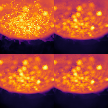

In [4]:
cam = perspective_camera(eye(0.3,0.2,0.24), bc; fov_deg=55); px=[0.4,:kpc]
tiles = [as_image(render_view(vol, cam; pxsize=px, mode=m, aa=2); colormap=:inferno) for m in (:max,:emission,:rt,:sum)]
vcat(hcat(tiles[1],tiles[2]), hcat(tiles[3],tiles[4]))   # :max | :emission  /  :rt | :sum

## 3 · Reconstruction (`smooth=`) — and what it costs

`false` = nearest-leaf (blocky, fast), `true` = cross-level **trilinear** (de-blocked, conservative —
default), `:kernel` = cubic B-spline (softest, but **cosmetic & non-conservative**, ~8× slower — beauty
frames only). The timings make the trade-off concrete.

> **Speckle / dots?** That's *aliasing* — at `aa=1` each pixel is one ray, so a clumpy field samples unevenly. Raise **`aa=2`–`3`** (supersampling) to smooth it; `smooth=:kernel` additionally softens coarse-cell facets in the integrating modes. Use `aa=1` only for quick previews.


smooth=false    0.06 s


smooth=true     0.22 s


smooth=kernel   1.24 s


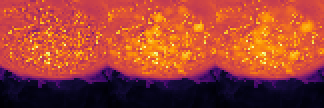

In [5]:
render_view(vol, cam; pxsize=px, mode=:max, smooth=false)   # warm up
for s in (false, true, :kernel)
    t = @elapsed render_view(vol, cam; pxsize=px, mode=:max, smooth=s)
    println(rpad("smooth=$s", 16), round(t, digits=2), " s")
end
hcat(as_image(render_view(vol,cam;pxsize=px,mode=:max,smooth=false); colormap=:inferno),
     as_image(render_view(vol,cam;pxsize=px,mode=:max,smooth=true);  colormap=:inferno),
     as_image(render_view(vol,cam;pxsize=px,mode=:max,smooth=:kernel);colormap=:inferno))

## 4 · The colour range (transfer function)

`render_view` returns the raw field; you set how it maps to colour when you display it. **`vmin`/`vmax`**
fix the range (in **log10** units when `logscale=true`, default) — values outside clip. Raise `vmin` to
hide a faint background; lower `vmax` to bring out faint structure. (For emission, `power>1` compresses
toward bright peaks at the ray-cast stage.)

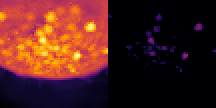

In [6]:
em = render_view(vol, cam; pxsize=px, mode=:emission, aa=2)
hcat(view_figure(em; colormap=:inferno),                       # auto range
     view_figure(em; colormap=:inferno, vmin=0.5, vmax=3.0))   # fixed log10 range (clips)

## 5 · The coarse-halo artefact — shown, then fixed

A 360° **equirectangular** view from the box centre integrates radially through the low-resolution halo, so
`:emission`/`:rt` can look blocky above the disk (the halo's real AMR cell structure, stretched by the log
display). `:max` hides it; `smooth=:kernel` softens the facets; a `subregion` removes the halo from the
line of sight. Not a bug — it's the data's resolution. Use `aa≥2` (jittered) for clean panoramas.
>
> **Rings / lattice dots?** If the camera sits exactly on a grid axis (e.g. straight down z, or at the exact box centre), rays related by that symmetry cross the axis-aligned cells identically → concentric-ring or dotted aliasing that supersampling/jitter can't remove. **Offset the camera slightly off-axis** (a small lateral term in `eye`) and it disappears.


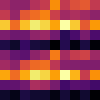

In [7]:
ec = equirect_camera(bc .+ (0.37, 0.21, 0.13))   # nudge off the exact (grid-aligned) centre → fewer lattice dots
hcat0 = view_figure(render_view(vol, ec; pxsize=[0.3,:kpc], mode=:emission, aa=2); colormap=:inferno)
hcatk = view_figure(render_view(vol, ec; pxsize=[0.3,:kpc], mode=:emission, aa=2, smooth=:kernel); colormap=:inferno)
vcat(hcat0, hcatk)    # top: trilinear (halo facets)   bottom: kernel (softened)

## 6 · Cameras & physical pixels

`perspective_camera` (navigation/fly-in), `equirect_camera` (360° survey), `fisheye_camera` (dome).
**`pxsize=[v,:kpc]`** sets the pixel size *at the box centre* (overrides `res`) → consistent physical
resolution across zooms, exactly like `projection`. Smaller `pxsize` = more pixels = larger image (slower).

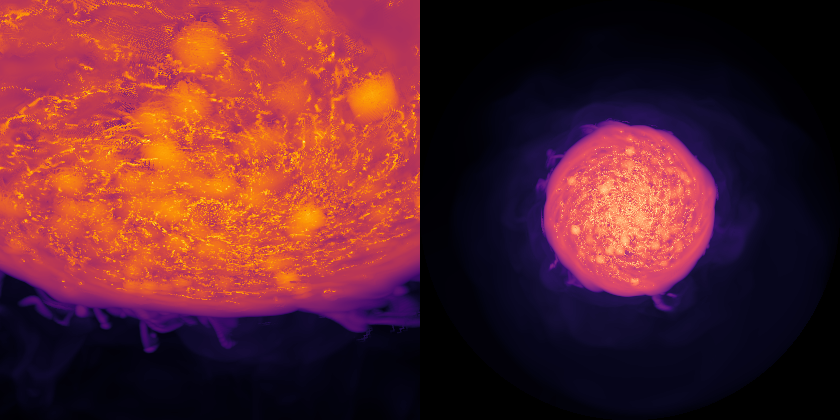

In [8]:
# same `res` → equal heights so hcat works (pxsize also works, but gives view-dependent sizes)
p = view_figure(render_view(vol, perspective_camera(eye(0.28,0.18,0.22), bc; fov_deg=55);
                            res=420, mode=:max, aa=2); colormap=:inferno)
f = view_figure(render_view(vol, fisheye_camera(eye(0,0,0.4), bc; fov_deg=180);
                            res=420, mode=:max, aa=2); colormap=:magma)
hcat(p, f)

## Planning the view — coordinate overlay

`overlay_grid(img, cam; vol, box, axes, graticule)` draws the **view's coordinate system** onto a render so
you can plan camera placement/orientation: the simulation **bounding-box wireframe**, the **world x/y/z axes**
(red/green/blue, from the origin), and a **graticule** (lon/lat meridians + parallels) for equirect/fisheye.
Lines are projected through the camera, so they curve correctly in the panoramas.

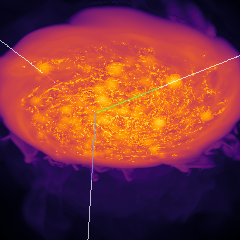

In [9]:
# box wireframe + world axes on a perspective view (planning aid)
ocam = perspective_camera(eye(0.45,0.3,0.35), bc; fov_deg=50)
img  = render_view(vol, ocam; pxsize=[0.12,:kpc], mode=:max, aa=2)
scene_figure(overlay_grid(img, ocam; vol=vol, box=true, axes=true, color=(1,1,1), alpha=0.7))

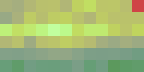

In [10]:
# lon/lat graticule on a 360° panorama (+ the box outline)
eg = equirect_camera(bc .+ (0.4,0.2,0.1))
pan = render_view(vol, eg; pxsize=[0.25,:kpc], mode=:emission, aa=2)
scene_figure(overlay_grid(pan, eg; vol=vol, graticule=true, graticule_deg=30, box=true, axes=false,
                          color=(0.6,1.0,0.6), alpha=0.6))

## 7 · `subregion` is the zoom **and** speed lever

`res`/`pxsize` set image size; **`subregion` sets how much data each ray traverses.** Indexing only the
region you'll view cuts both RAM and time. Rough cost: `res² · steps · leaf_cost · (trilinear? 8 : 1) / nthreads`.

[Mera] Tip: regions also work as value types with EXACT edge-cell splitting (exact getvar :mass/:volume/msum), composable with ∩ ∪ \ !:
           subregion(data, Cylinder(5.0, 1.5; center=[:boxcenter], range_unit=:kpc))


           (the symbol form above still works; pass split=false for classic whole cells. Shown once per session — see ?subregion.)
[Mera]: 2026-07-02T10:53:14.986



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]
ymin::ymax: 0.3958333 :: 0.6041667  	==> 19.0 [kpc] :: 29.0 [kpc]
zmin::zmax: 0.46875 :: 0.53125  	==> 22.5 [kpc] :: 25.5 [kpc]

Radius: 5.0 [kpc]
Height: 1.5 [kpc]
Memory used for data table :

4.217771562747657 GB
-------------------------------------------------------



┌ Warning: amr_volume indexed 51463597 leaves (~2.1 GB of index, lookups descend 5 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122


full nleaf = 166991609   cylinder nleaf = 51463597


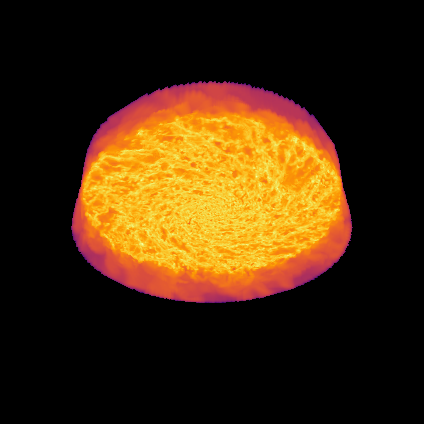

In [11]:
# MEMORY: a subregion copies its cells; for a galaxy most cells live in the disk, so a *large* cylinder
# barely shrinks the data and — built on top of the full `vol` (~7 GB here) — can exhaust RAM and kill the
# kernel. Keep the zoom SMALL and GC temporaries. (If RAM is tight, restart and subregion `gas` in cell 1.)
sub  = subregion(gas, :cylinder; center=[:boxcenter], radius=5., height=1.5, direction=:z, range_unit=:kpc)
volS = amr_volume(sub, :rho, :nH; verbose=false)
println("full nleaf = ", vol.nleaf, "   cylinder nleaf = ", volS.nleaf)   # far fewer cells = less RAM, faster
sub = nothing; GC.gc()
view_figure(render_view(volS, perspective_camera(eye(0.25,0.18,0.22), bc; fov_deg=50);
                        pxsize=[0.04,:kpc], mode=:max, aa=2); colormap=:inferno)

## 8 · `render_scene` — the multi-tracer layer cake

Composite layers, each with its own colormap + opacity. Build it up: density → colour it by temperature
(opacity from ρ, **hue from T**) → add self-absorption (`absorb_by`) → add stars (`points_channel`).
`opacity`/`kappa`/`absorb_*` are **normalized visual dials** (not physical optical depth). Stars need the
particle files; if unavailable the cell skips them.
>
> **`shade=` for form/depth.** Flat emission-absorption looks like colour patches; `shade` (0–1) lights each gas sample by its density **gradient** (ParaView's 'Shade') so clumps gain 3-D relief. Pair with a calmer colormap + `gamma>1` to avoid an over-saturated look.


┌ Warning: amr_volume indexed 104570892 leaves (~4.2 GB of index, lookups descend 5 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122
┌ Warning: amr_volume indexed 104570892 leaves (~4.2 GB of index, lookups descend 5 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122


┌ Warning: particles unavailable — skipping stars (CompositeException)
└ @ Main In[12]:12


render_scene   1%|▎                                     |  ETA: 0:09:26

render_scene  10%|████                                  |  ETA: 0:00:44

render_scene  17%|██████▌                               |  ETA: 0:00:27

...

render_scene  98%|█████████████████████████████████████▍|  ETA: 0:00:01

render_scene  99%|█████████████████████████████████████▌|  ETA: 0:00:01

render_scene  99%|█████████████████████████████████████▊|  ETA: 0:00:01

render_scene  99%|█████████████████████████████████████▉|  ETA: 0:00:00

render_scene 100%|██████████████████████████████████████| Time: 0:01:26

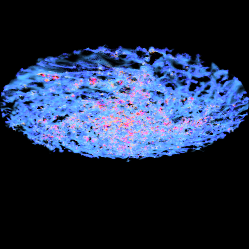

In [12]:
scam = perspective_camera(eye(0.34,0.10,0.16), bc; fov_deg=50); spx=[0.07,:kpc]
# multi-tracer scene builds several full-box indices; on 32 GB build them on a subregion
# (same boxlen/center, so the full-box camera is unchanged), then free them.
g21  = subregion(gas, :cylinder; center=[:boxcenter], radius=8., height=2.5, direction=:z, range_unit=:kpc, verbose=false)
gch = field_channel(g21, :rho, :nH; color_by=:T, color_unit=:K, colormap=:RdYlBu, reverse=true,
                    vmin=-0.5, vmax=2.3, color_vmin=3.5, color_vmax=6.5, opacity=12, gamma=1.4)
stars = try
    parts = getparticles(info, verbose=false, show_progress=false)   # or loaddata(390, path, :particles)
    age = getvar(parts, :age, :Myr)
    [points_channel(parts; filter=age.<50, weight=:mass, color=(0.4,0.9,1.0), size=1.0, opacity=0.5),  # young = blue
     points_channel(parts; filter=age.>800, weight=:mass, color=(1.0,0.8,0.4), size=0.7, opacity=0.12)] # old = amber
catch e; @warn "particles unavailable — skipping stars ($(typeof(e)))"; []
end
fig21 = scene_figure(render_scene([gch; stars], scam; pxsize=spx, aa=2, exposure=2.4, saturation=1.4,
                          shade=0.8, light=(-1,-0.5,1), show_progress=true))
gch = nothing; g21 = nothing; GC.gc()
fig21

## 9 · Isosurfaces — physical value-surfaces

`mode=:iso`, `level` = the field's **physical value** (linear, in the volume's unit; any real). `iso_alpha<1`
makes shells translucent; pass a **vector** of levels for nested shells in one pass (depth-ordered).

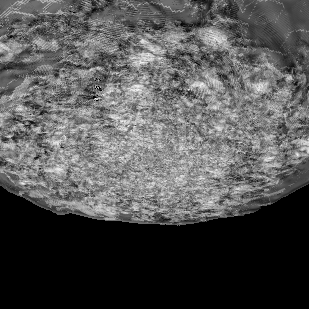

In [13]:
icam = perspective_camera(eye(0.30,0.20,0.24), bc; fov_deg=55)
as_image(render_view(vol, icam; pxsize=[0.07,:kpc], mode=:iso, level=[0.1,1.0,10.0], iso_alpha=0.3, aa=2);
         colormap=:bone, logscale=false)

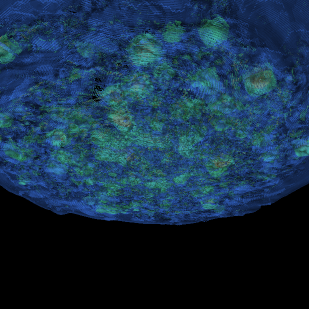

In [14]:
# each isosurface in its OWN colour (gradient-shaded shells + ambient occlusion for depth)
render_isosurfaces(vol, icam; pxsize=[0.07,:kpc], aa=2, ao=0.7,
    levels=[0.1, 1.0, 10.0], colors=[(0.25,0.5,1.0), (0.3,1.0,0.4), (1.0,0.45,0.2)], iso_alpha=0.35)

## 10 · Quantitative science — numbers you can compare to data

These return **physical maps**, not just pretty pictures.

> **Read the values:** `view_colorbar(map; vmin, vmax, logscale, colormap, label)` shows a scalar map with an **aligned, labelled colorbar** (and `filename=` to save). Use it instead of `view_figure` whenever the numbers matter (column density, velocity, dispersion).


**Column density** `N_H` [cm⁻²]: `column_map` = `∫ nH dl` with the path length in cm (via the volume's scale).

log10 N_H range: (

19.71, 23.11)


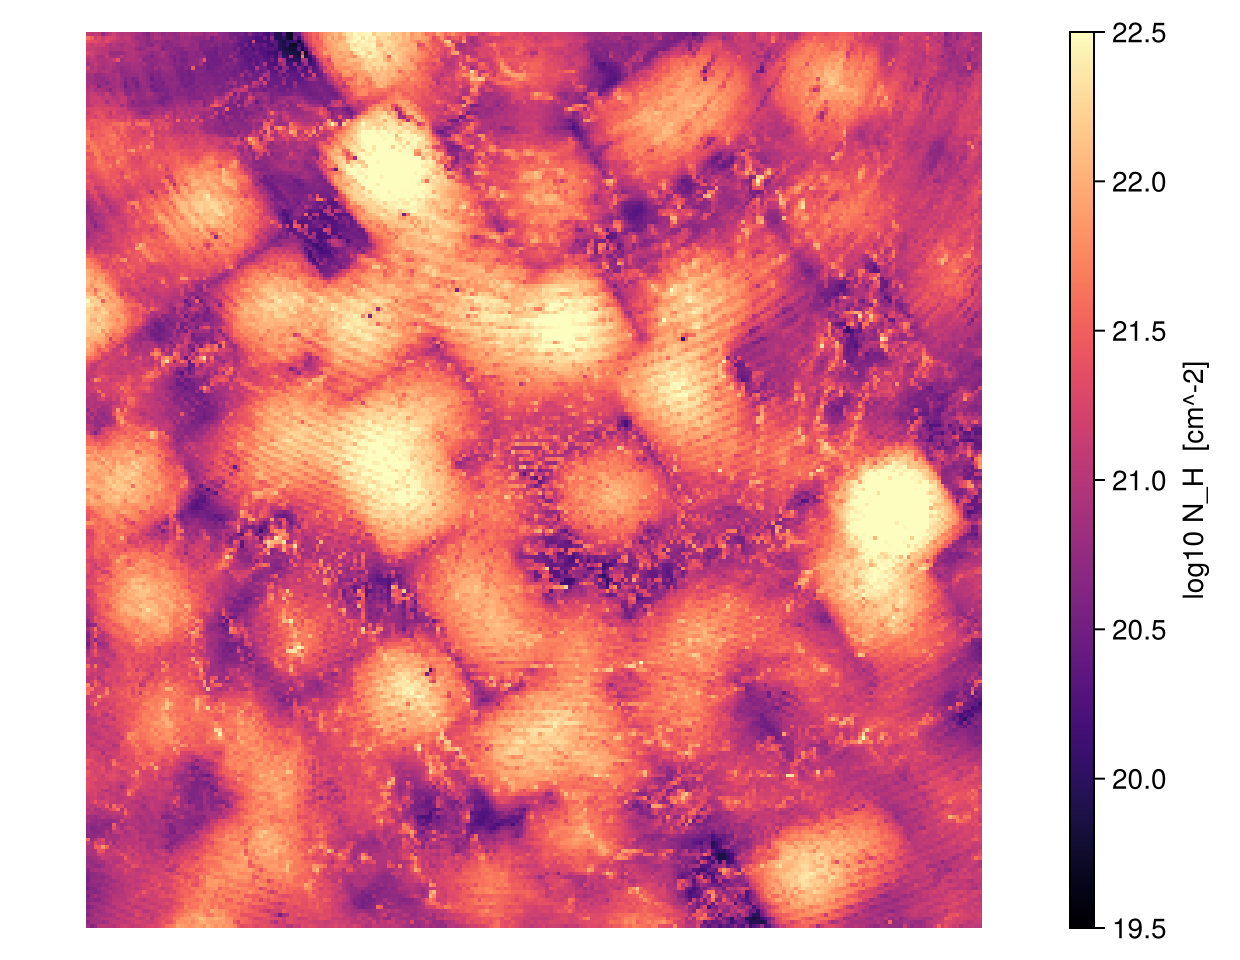

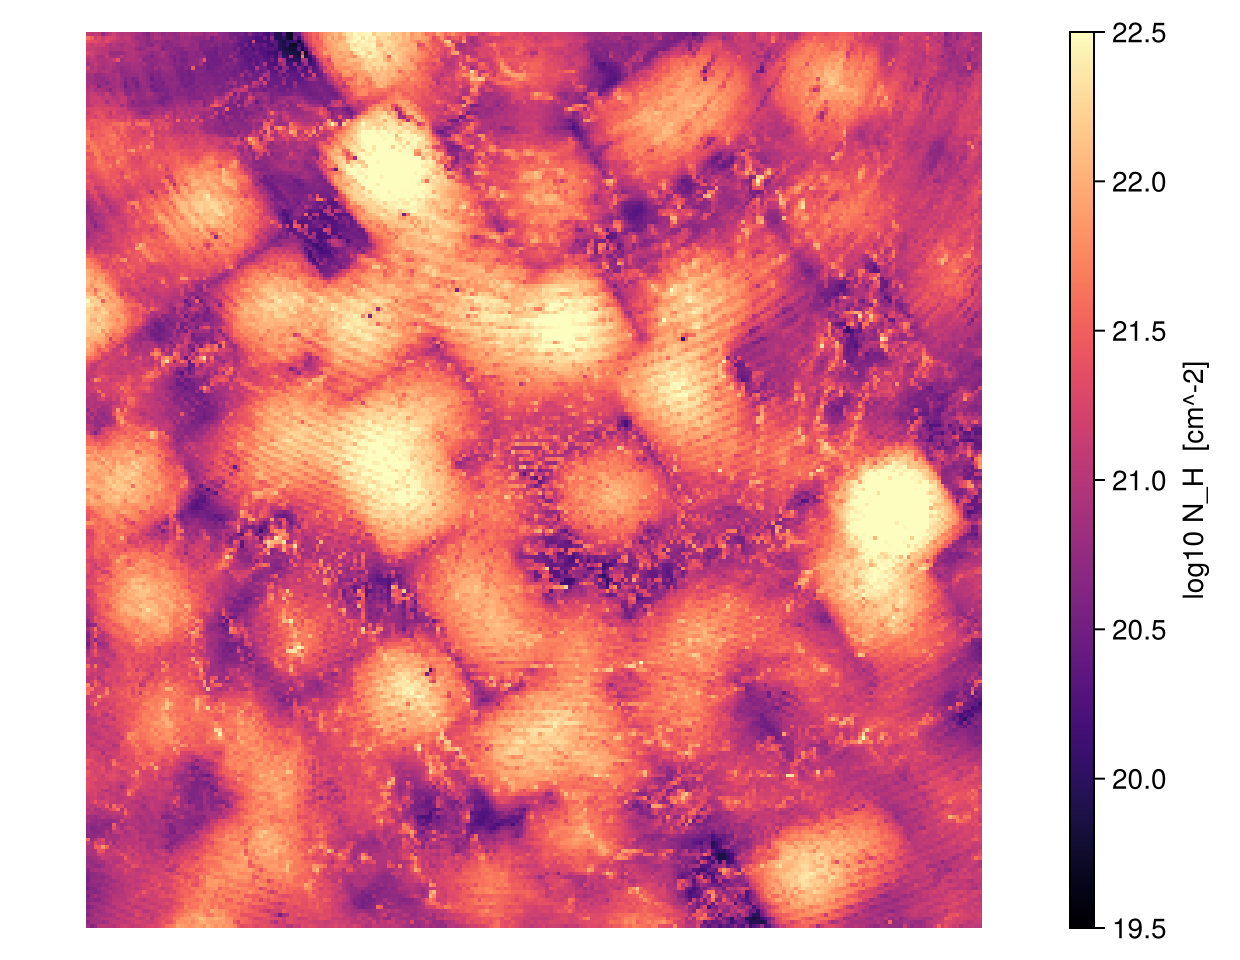

In [15]:
NH = column_map(vol, perspective_camera(eye(0.12,0.08,0.62), bc; fov_deg=22); pxsize=[0.05,:kpc], aa=2)  # OFF-axis: no rings   # ~face-on
println("log10 N_H range: ", round.(extrema(filter(isfinite, log10.(NH[NH.>0]))), digits=2))
view_colorbar(NH; colormap=:magma, vmin=19.5, vmax=22.5, label="log10 N_H  [cm^-2]")

**Mock emission** from a derived emissivity (here thermal bremsstrahlung `∝ n²√T`), rendered as a `:sum` surface brightness.

┌ Warning: amr_volume indexed 166991609 leaves (~6.7 GB of index, lookups descend 8 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122


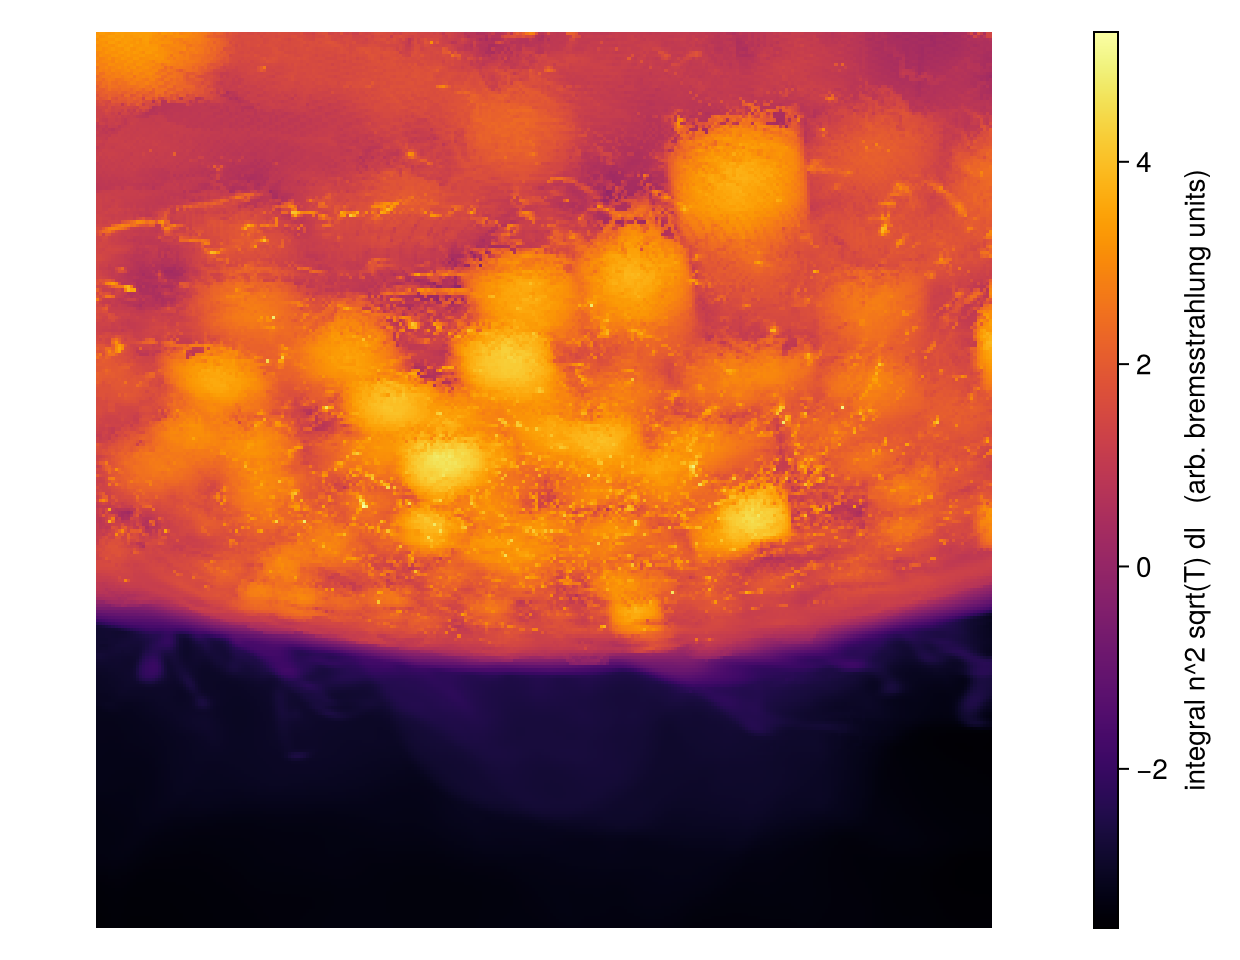

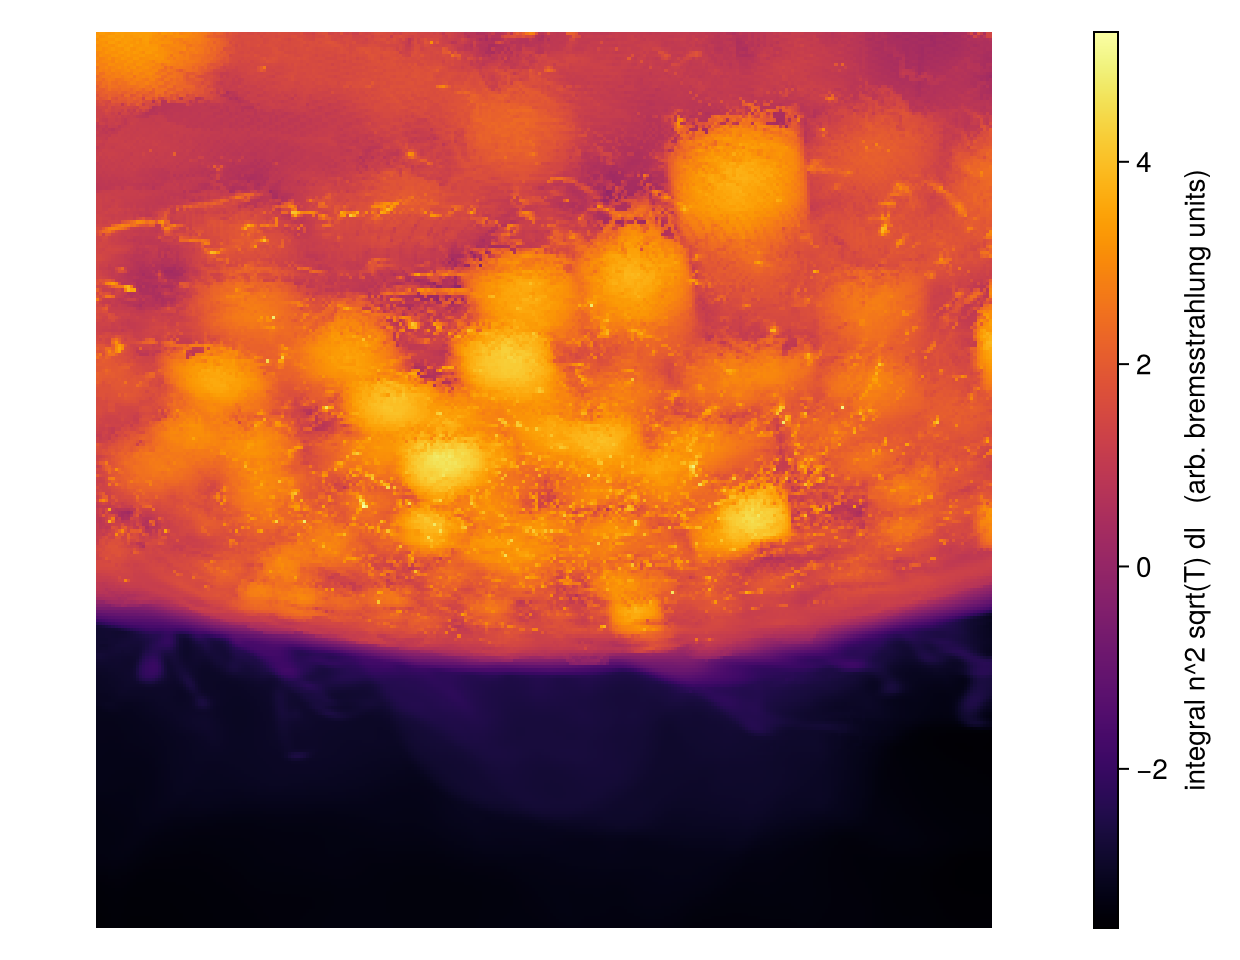

In [16]:
xray = derived_volume(gas, (n,T)->n^2*sqrt(T), [:rho,:T]; units=[:nH,:K], verbose=false)
figx = view_colorbar(render_view(xray, scam; pxsize=[0.06,:kpc], mode=:sum, aa=2); colormap=:inferno,
              label="integral n^2 sqrt(T) dl   (arb. bremsstrahlung units)")
xray = nothing; GC.gc()          # free the extra full-box index before the next cell
figx

**Line-of-sight kinematics** (moment maps), evaluated per ray so they're correct for perspective.
`moment1` = mean v∥ (**+ = receding**); colour it with a diverging map. Velocity volumes need `signed=true`.

┌ Warning: amr_volume indexed 72312794 leaves (~2.9 GB of index, lookups descend 5 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122
┌ Warning: amr_volume indexed 72312794 leaves (~2.9 GB of index, lookups descend 5 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122


┌ Warning: amr_volume indexed 72312794 leaves (~2.9 GB of index, lookups descend 5 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122
┌ Warning: amr_volume indexed 72312794 leaves (~2.9 GB of index, lookups descend 5 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122


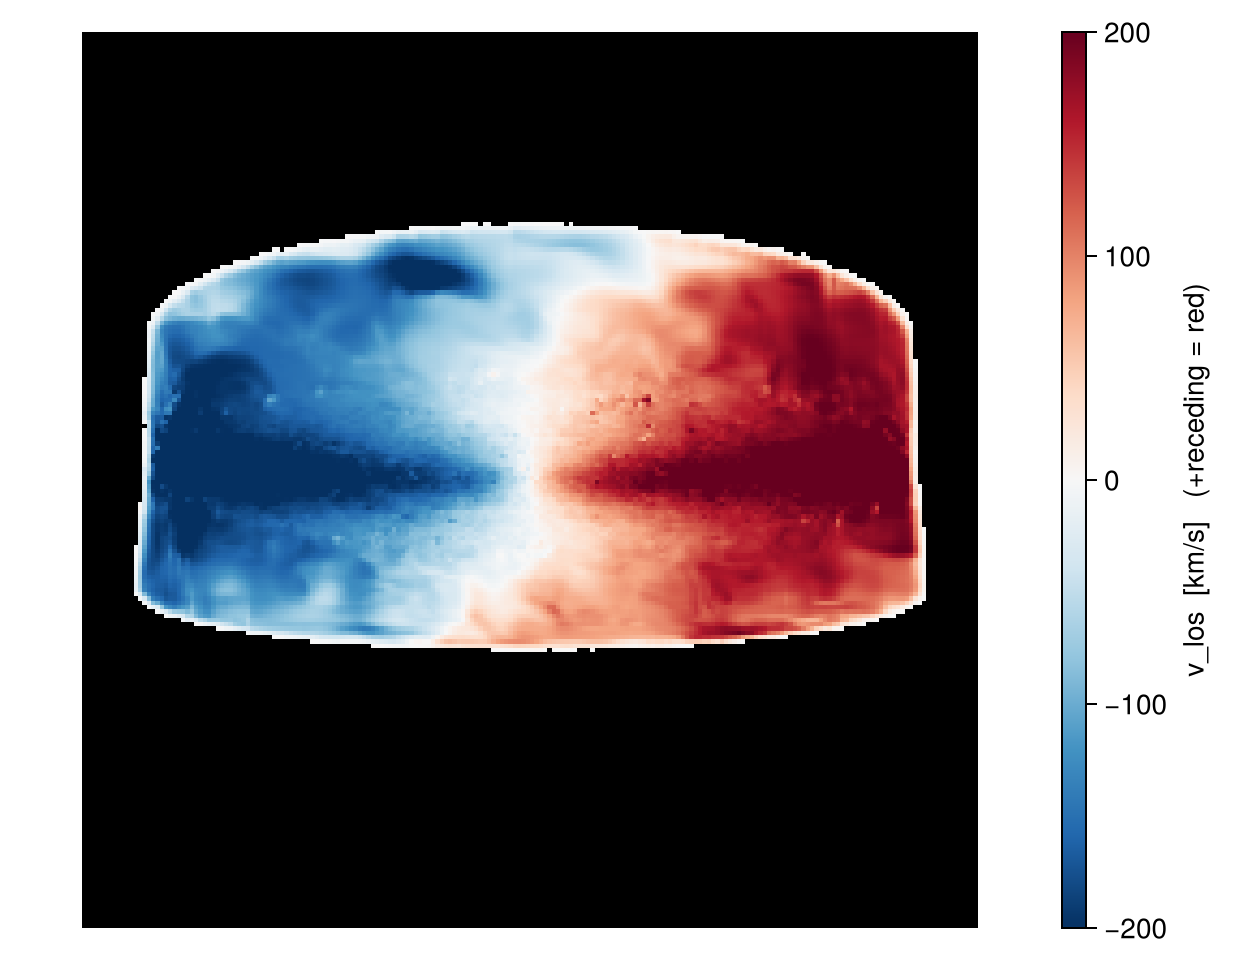

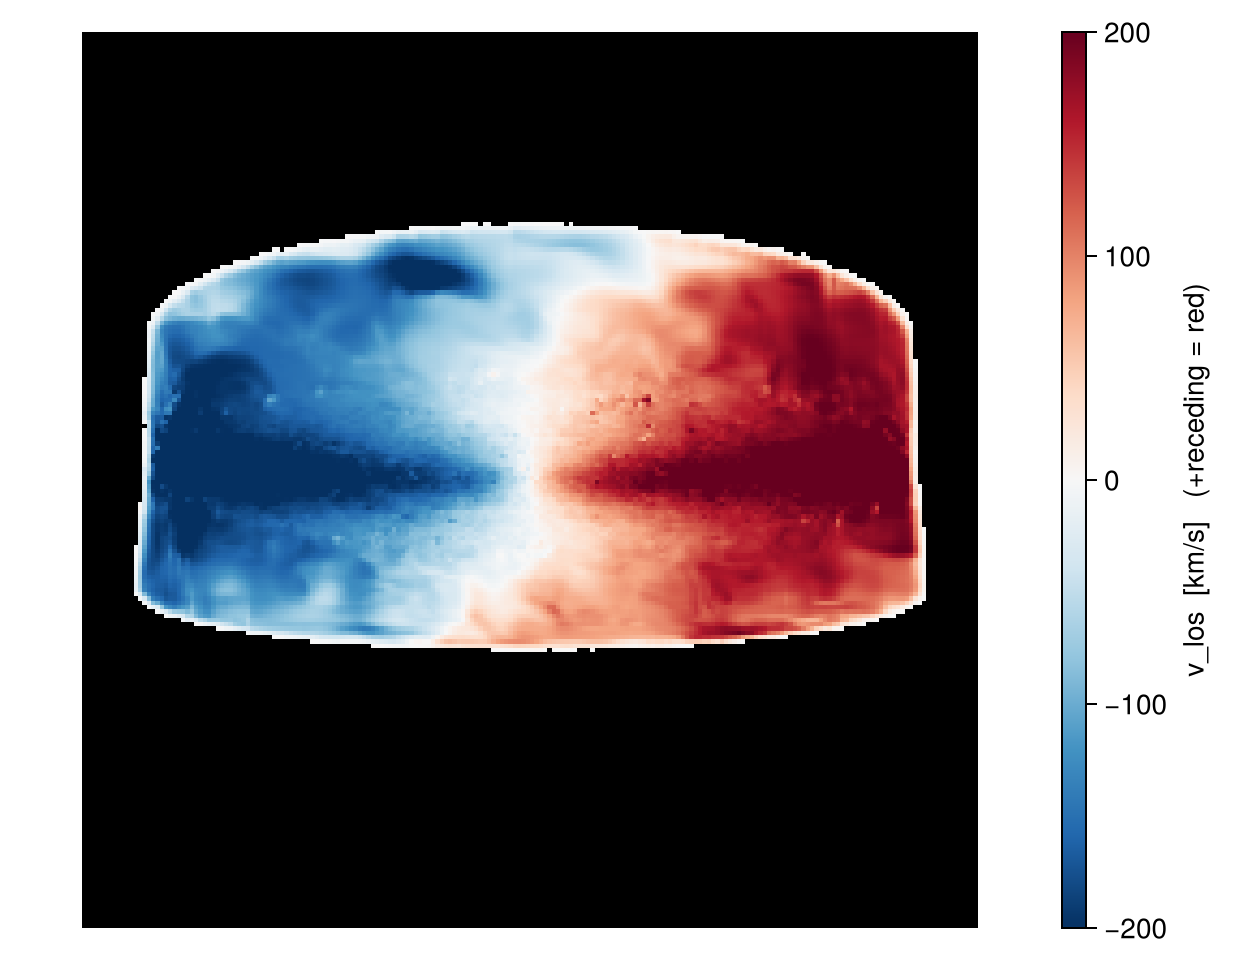

In [17]:
# moment maps need vol+vx+vy+vz simultaneously — 4 full 167M indices would exceed 32 GB RAM (-> swap).
# Build them together on a subregion (the rotating disk); same boxlen/center, so the camera is unchanged.
msub = subregion(gas, :cylinder; center=[:boxcenter], radius=6., height=2., direction=:z, range_unit=:kpc, verbose=false)
volm = amr_volume(msub, :rho, :nH; verbose=false)
vx   = amr_volume(msub, :vx, :km_s; signed=true, verbose=false)
vy   = amr_volume(msub, :vy, :km_s; signed=true, verbose=false)
vz   = amr_volume(msub, :vz, :km_s; signed=true, verbose=false)
msub = nothing; GC.gc()
m0, m1, m2 = moment_maps(volm, vx,vy,vz, perspective_camera(eye(0.05,0.55,0.12), bc; fov_deg=30); pxsize=[0.07,:kpc], aa=2)
vx = vy = vz = volm = nothing; GC.gc()
view_colorbar(m1; colormap=:RdBu, reverse=true, logscale=false, vmin=-200, vmax=200,
              label="v_los  [km/s]   (+receding = red)")   # rotation curve, readable in km/s
# m0 = intensity (integral rho dl), m2 = dispersion:  view_colorbar(m2; logscale=false, colormap=:viridis, label="sigma_los [km/s]")

**Inflow / outflow** in one image: density (opacity) coloured by **vertical velocity** `vz` (the
galactic fountain — up vs down out of the disk). Signed colour field + diverging map + symmetric range.

┌ Warning: amr_volume indexed 104570892 leaves (~4.2 GB of index, lookups descend 5 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122
┌ Warning: amr_volume indexed 104570892 leaves (~4.2 GB of index, lookups descend 5 levels). For a big box, `subregion(data, …)` before amr_volume indexes only the zoom region — far less RAM and much faster.
└ @ Mera ~/code-github/Mera.jl/src/functions/immersive.jl:122


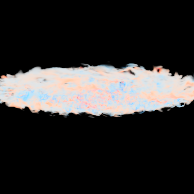

In [18]:
# density (opacity) coloured by vertical velocity — build the channel on a subregion (memory-safe on 32 GB)
g33  = subregion(gas, :cylinder; center=[:boxcenter], radius=8., height=2.5, direction=:z, range_unit=:kpc, verbose=false)
wind = field_channel(g33, :rho, :nH; color_by=:vz, color_unit=:km_s, color_signed=true,
                     color_logscale=false, colormap=:RdBu, color_vmin=-80, color_vmax=80,
                     vmin=-1.0, vmax=2.0, opacity=6)
fig33 = scene_figure(render_scene([wind], perspective_camera(eye(0.05,0.5,0.1), bc; fov_deg=35);
                          pxsize=[0.08,:kpc], aa=2, exposure=1.8))
wind = nothing; g33 = nothing; GC.gc()
fig33

## 11 · Animation

`orbit_keyframes` → `flythrough_montage` (a still contact sheet, shown here) → `flythrough` (mp4; needs
`CairoMakie`). `flythrough` also accepts a **vector of channels** for ρ+T+stars movies.

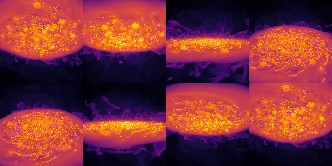

In [19]:
kf = orbit_keyframes(bc, 0.45*vol.boxlen; inclination=35, n=10)
flythrough_montage(vol, :perspective, kf; nframes=8, cols=4, pxsize=[0.3,:kpc], mode=:max)
# movie:        flythrough(vol, :perspective, kf; nframes=96, pxsize=[0.15,:kpc], filename="orbit.mp4")
# multi-tracer: flythrough([gch; stars], :perspective, kf; nframes=96, pxsize=[0.12,:kpc], filename="scene.mp4")

**Interactive orbit** (live, needs `using GLMakie`): `interactive_view(vol; mode=:max)` — or a
scene: `interactive_view([gch; stars])`. Left-drag to orbit, scroll to zoom (coarse while moving, crisp on release).

## Parameters & tuning — the dials

| Want to change… | Parameter | Where |
|---|---|---|
| Viewpoint / zoom | `pos`, `target`, `fov_deg` | `perspective_camera` |
| View type | perspective / `equirect` (360°) / `fisheye` (dome) | camera constructor |
| Resolution | **`pxsize`** (`[v,:unit]`, overrides `res`) | `render_view`/`render_scene` |
| Smoothness / AA | `smooth` (`false`/`true`/`:kernel`), `aa`, `jitter` | render |
| Accumulation | `mode` (`:max`/`:emission`/`:rt`/`:sum`/`:iso`) | `render_view` |
| Isosurface | `mode=:iso`, `level` (scalar or **vector**), `iso_alpha`, lighting | `render_view` |
| Displayed colour range | `vmin`/`vmax` (log10), `colormap`, `logscale` | `view_figure`/`as_image`/`save_view` |
| Colour by 2nd field | `color_by`, `color_vmin/vmax`, `color_signed` | `field_channel` |
| Absorption field | `absorb_by`, `absorb_vmin/vmax` | `field_channel` |
| Look | `opacity`, `gamma`, `exposure`, `saturation` | `field_channel`/`render_scene` |
| Stars | `weight`, `filter`, `color`, `size`, `opacity` | `points_channel` |
| **Quantitative** | `column_map` (N_H), `derived_volume` (mock emission), `moment_maps` (kinematics) | — |
| **Speed** | 8-thread kernel · `subregion` · occupancy (auto, `set_occupancy`) · `smooth=false`/coarse `pxsize` previews | — |
| **Save** | `save_view` (scalar) · `save_scene` (RGB) · `save_figure` (either) | — |

**Concepts & references:** emission–absorption volume rendering (Max 1995); front-to-back compositing
(Porter & Duff 1984); transfer functions / coloured-density (Levoy 1988); trilinear reconstruction (Engel
et al. 2006); ACES tone-map (Narkowicz 2016); equirectangular (Snyder 1987); fisheye (Bourke 2004);
Catmull–Rom paths (1974).